In [ ]:
from mnist import load_mnist

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
train, validation, test = load_mnist()

Extracting MNIST-data\train-images-idx3-ubyte.gz
Extracting MNIST-data\train-labels-idx1-ubyte.gz
Extracting MNIST-data\t10k-images-idx3-ubyte.gz
Extracting MNIST-data\t10k-labels-idx1-ubyte.gz


In [ ]:
print(type(train), " ", np.shape(train[0]))


<class 'tuple'>   (55000, 28, 28, 1)


In [ ]:
N = 20000

X_pr = train[0][:N]
y = train[1][:N]


(20000, 28, 28, 1)

In [ ]:
from tqdm.notebook import tqdm

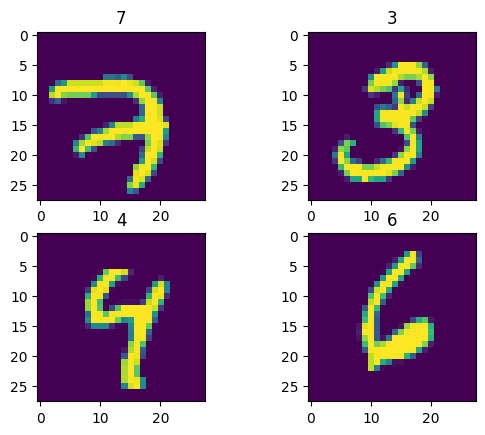

In [ ]:
N_k = 2
figure, axis = plt.subplots(N_k, N_k)
for i in range(N_k):
    for j in range(N_k):
        axis[i, j].imshow(X_pr[N_k*i + j])
        axis[i, j].set_title(y[N_k*i + j])

plt.show()

In [ ]:
X = np.array(X_pr.reshape((N, 784)), dtype=float) / 256

In [ ]:
class my_PCA():
    def __init__(self, n_components=2):
        self.n_components = n_components

    def fit(self, X):
        self.X_c = X - X.mean(axis=0)
        self.C = np.dot(self.X_c.T, self.X_c)
        L, F = np.linalg.eigh(self.C)
        self.L = np.diag(L[::-1])
        self.F = F[:, ::-1]

    def transform(self, X_c=None):
        self.X_new = self.X_c.dot(self.F)


    def fit_transform(self, X):
        pass

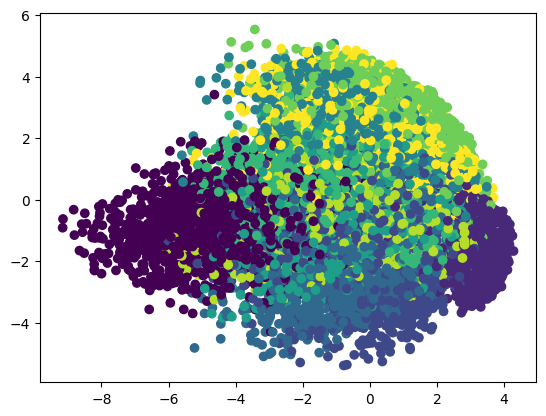

In [ ]:
# График на 2 главные координаты

pca = my_PCA()
pca.fit(X)
pca.transform()

plt.scatter(pca.X_new[:, 0], pca.X_new[:, 1], c=y)

In [ ]:
from tqdm.notebook import tqdm

class my_kNN():
    def __init__(self, n_neighbors=1):
        self.n_neighbors = n_neighbors

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test):
        y_predict = np.zeros(len(X_test))
        distances = np.zeros((len(X_test), len(self.X_train)))
        k_nearest_indexes = np.zeros((len(X_test), self.n_neighbors), dtype="int")
        targets = np.zeros((len(X_test), self.n_neighbors), dtype="int")

        for i in tqdm(range(len(X_test))):
            for j in range(len(self.X_train)):
                distances[i, j] = np.sqrt(np.sum((self.X_train[j] - X_test[i]) ** 2))

        for i in range(len(X_test)):
            k_nearest_indexes[i] = np.argsort(distances[i])[:self.n_neighbors]

        for i in range(len(X_test)):
            targets[i] = self.y_train[k_nearest_indexes[i]]

        for i in range(len(X_test)):
            y_predict[i] = np.bincount(targets[i]).argmax()

        return y_predict

In [ ]:
X_c = X - X.mean(axis=0)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_c, y, test_size=0.3, random_state=10)

In [ ]:
myknn = my_kNN()
myknn.__init__(150)
myknn.fit(X_train, y_train)
y_pred = myknn.predict(X_test)

temp = y_pred-y_test
print("Верно определено:", np.count_nonzero(temp == 0), "  Не верно определено:", np.count_nonzero(temp != 0))
print("В процентах: ", np.count_nonzero(temp == 0)/len(y_pred))

  0%|          | 0/6000 [00:00<?, ?it/s]

Верно определено: 5312   Не верно определено: 688
В процентах:  0.8853333333333333


In [ ]:
#опять же, я списал всё у Димы(